In [135]:

# =========================
# 1. User configuration
# =========================

from pathlib import Path
import os
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 修改为你的 Design Judge 输出目录
OUTPUT_DIR = Path(r"..\Judge_output\_DesignJudge_claude2")

# 图像输出目录
FIG_DIR = OUTPUT_DIR / "_paper_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# 是否保存 PDF / SVG / PNG
SAVE_PNG = True
SAVE_PDF = True
SAVE_SVG = True

# 图片分辨率
DPI = 600

# 字体设置：Windows 下推荐 Arial；中文需要时可换 SimHei/Microsoft YaHei
plt.rcParams["font.family"] = "Arial"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

print("OUTPUT_DIR:", OUTPUT_DIR)
print("FIG_DIR:", FIG_DIR)


OUTPUT_DIR: ..\Judge_output\_DesignJudge_claude2
FIG_DIR: ..\Judge_output\_DesignJudge_claude2\_paper_figures


In [137]:

# =========================
# 2. Paths and constants
# =========================

PATHS = {
    "avg_candidate_case": OUTPUT_DIR / "3_item_scores_average_per_candidate.csv",
    "final_candidate": OUTPUT_DIR / "4_final_scores_by_candidate.csv",
    "final_family_mean": OUTPUT_DIR / "5_final_scores_by_family_mean.csv",
    "final_family_best": OUTPUT_DIR / "6_final_scores_by_family_best.csv",
    "matrix_family_mean": OUTPUT_DIR / "8_case_family_mean_overall_matrix.csv",
    "exploration": OUTPUT_DIR / "14_family_similarity_and_exploration.csv",
    "family_mean_with_exploration": OUTPUT_DIR / "15_final_scores_by_family_mean_with_exploration.csv",
}

METRIC_COLUMNS = [
    "Chemical_Feasibility",
    "Scientific_Rigor",
    "Mechanistic_Coherence",
    "Property_Constraint_and_Tradeoff_Handling",
    "Design_Completeness",
    "Risk_and_Uncertainty_Awareness",
    "Design_Innovation_and_Exploration",
]

METRIC_LABELS = {
    "Chemical_Feasibility": "Chemical\nfeasibility",
    "Scientific_Rigor": "Scientific\nrigor",
    "Mechanistic_Coherence": "Mechanistic\ncoherence",
    "Property_Constraint_and_Tradeoff_Handling": "Constraint &\ntrade-off",
    "Design_Completeness": "Design\ncompleteness",
    "Risk_and_Uncertainty_Awareness": "Risk &\nuncertainty",
    "Design_Innovation_and_Exploration": "Innovation &\nexploration",
}

FAMILY_ORDER = [
    "BEAVER",
    "GPT5.5",
    "Gemini3.1-pro",
    "DeepSeek-V4-pro",
    "Qwen3.5-Plus",
]

FAMILY_DISPLAY = {
    "BEAVER": "BEAVER",
    "GPT5.5": "GPT-5.5",
    "Gemini3.1-pro": "Gemini 3.1 Pro",
    "DeepSeek-V4-pro": "DeepSeek-V4-Pro",
    "Qwen3.5-Plus": "Qwen3.5-Plus",
}

# 统一颜色。可按期刊风格自行替换。
COLOR_MAP = {
    "BEAVER": "#1f77b4",
    "GPT5.5": "#ff7f0e",
    "Gemini3.1-pro": "#2ca02c",
    "DeepSeek-V4-pro": "#d62728",
    "Qwen3.5-Plus": "#9467bd",
}

CASE_DISPLAY = {
    "热学+降解": "Thermal–Degradation",
    "力学+降解": "Mechanical–Degradation",
    "力学+热学": "Mechanical–Thermal",
    "力学+热学+降解": "Mechanical–Thermal–Degradation",
}

def read_csv_if_exists(path: Path) -> pd.DataFrame:
    if path.exists():
        return pd.read_csv(path)
    print(f"[WARN] Missing file: {path}")
    return pd.DataFrame()

def savefig_multi(fig, name: str):
    stem = FIG_DIR / name
    if SAVE_PNG:
        fig.savefig(stem.with_suffix(".png"), dpi=DPI, bbox_inches="tight")
    if SAVE_PDF:
        fig.savefig(stem.with_suffix(".pdf"), bbox_inches="tight")
    if SAVE_SVG:
        fig.savefig(stem.with_suffix(".svg"), bbox_inches="tight")
    print("Saved:", stem)

def order_family_df(df: pd.DataFrame, family_col: str = "Family") -> pd.DataFrame:
    out = df.copy()
    out[family_col] = out[family_col].astype(str)
    out["__order"] = out[family_col].map({f:i for i, f in enumerate(FAMILY_ORDER)}).fillna(999)
    return out.sort_values(["__order", family_col]).drop(columns="__order").reset_index(drop=True)

def prettify_family(x):
    return FAMILY_DISPLAY.get(str(x), str(x))

def prettify_case(x):
    return CASE_DISPLAY.get(str(x), str(x))


In [139]:

# =========================
# 3. Load data
# =========================

df_avg = read_csv_if_exists(PATHS["avg_candidate_case"])
df_candidate = read_csv_if_exists(PATHS["final_candidate"])
df_family_mean = read_csv_if_exists(PATHS["final_family_mean"])
df_family_best = read_csv_if_exists(PATHS["final_family_best"])
df_matrix_family = read_csv_if_exists(PATHS["matrix_family_mean"])
df_exploration = read_csv_if_exists(PATHS["exploration"])
df_family_exp = read_csv_if_exists(PATHS["family_mean_with_exploration"])

if not df_family_mean.empty:
    df_family_mean = order_family_df(df_family_mean, "Family")
if not df_family_best.empty:
    df_family_best = order_family_df(df_family_best, "Family")
if not df_family_exp.empty:
    df_family_exp = order_family_df(df_family_exp, "Family")

print("df_avg:", df_avg.shape)
print("df_candidate:", df_candidate.shape)
print("df_family_mean:", df_family_mean.shape)
print("df_family_best:", df_family_best.shape)
print("df_matrix_family:", df_matrix_family.shape)
print("df_exploration:", df_exploration.shape)
print("df_family_exp:", df_family_exp.shape)

display(df_family_mean)


df_avg: (60, 17)
df_candidate: (15, 12)
df_family_mean: (5, 12)
df_family_best: (5, 12)
df_matrix_family: (4, 6)
df_exploration: (20, 10)
df_family_exp: (5, 17)


,Family,Candidate,Overall,ScoredCases,JudgeParseOK(%),Chemical_Feasibility,Scientific_Rigor,Mechanistic_Coherence,Property_Constraint_and_Tradeoff_Handling,Design_Completeness,Risk_and_Uncertainty_Awareness,Design_Innovation_and_Exploration
0,BEAVER,BEAVER_Mean,6.708,4,100.0,6.562,6.959,6.208,6.354,7.771,7.646,5.708
1,GPT5.5,GPT5.5_Mean,6.465,4,100.0,7.438,6.479,6.896,6.896,6.896,5.000,4.188
2,Gemini3.1-pro,Gemini3.1-pro_Mean,6.152,4,100.0,6.646,5.938,6.979,6.625,6.146,4.417,5.187
3,DeepSeek-V4-pro,DeepSeek-V4-pro_Mean,6.740,4,100.0,6.854,6.604,7.333,7.188,6.541,5.146,6.812
4,Qwen3.5-Plus,Qwen3.5-Plus_Mean,6.636,4,100.0,7.063,6.416,7.250,7.000,6.958,5.729,5.083


Saved: ..\Judge_output\_DesignJudge_claude2\_paper_figures\Fig1_family_mean_overall_bar


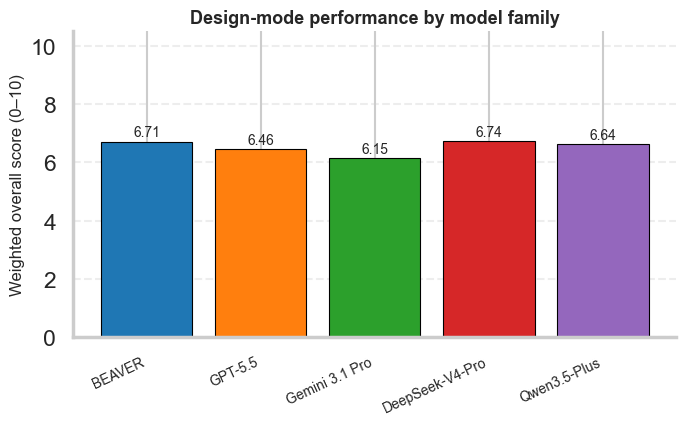

In [141]:

# =========================
# Figure 1. Overall score by family mean
# =========================

def plot_family_overall_bar(df_family_mean: pd.DataFrame):
    if df_family_mean.empty:
        print("No df_family_mean")
        return

    df = order_family_df(df_family_mean, "Family")
    labels = [prettify_family(x) for x in df["Family"]]
    values = df["Overall"].astype(float).values
    colors = [COLOR_MAP.get(f, "#777777") for f in df["Family"]]

    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    bars = ax.bar(np.arange(len(df)), values, color=colors, edgecolor="black", linewidth=0.8)

    for i, v in enumerate(values):
        ax.text(i, v + 0.08, f"{v:.2f}", ha="center", va="bottom", fontsize=10)

    ax.set_ylabel("Weighted overall score (0–10)", fontsize=12)
    ax.set_ylim(0, 10.5)
    ax.set_xticks(np.arange(len(df)))
    ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=10)
    ax.set_title("Design-mode performance by model family", fontsize=13, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()
    savefig_multi(fig, "Fig1_family_mean_overall_bar")
    plt.show()

plot_family_overall_bar(df_family_mean)


..\tmp\ipykernel_11624\603748486.py:61: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'black'}` instead.

  sns.barplot(
..\tmp\ipykernel_11624\603748486.py:61: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.6}` instead.

  sns.barplot(
..\tmp\ipykernel_11624\603748486.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(families, fontsize=FS_TICK, fontweight='bold', rotation=20, ha="right")


Saved: ..\Judge_output\_DesignJudge_claude2\_paper_figures\Fig2_family_mean_vs_best_styled


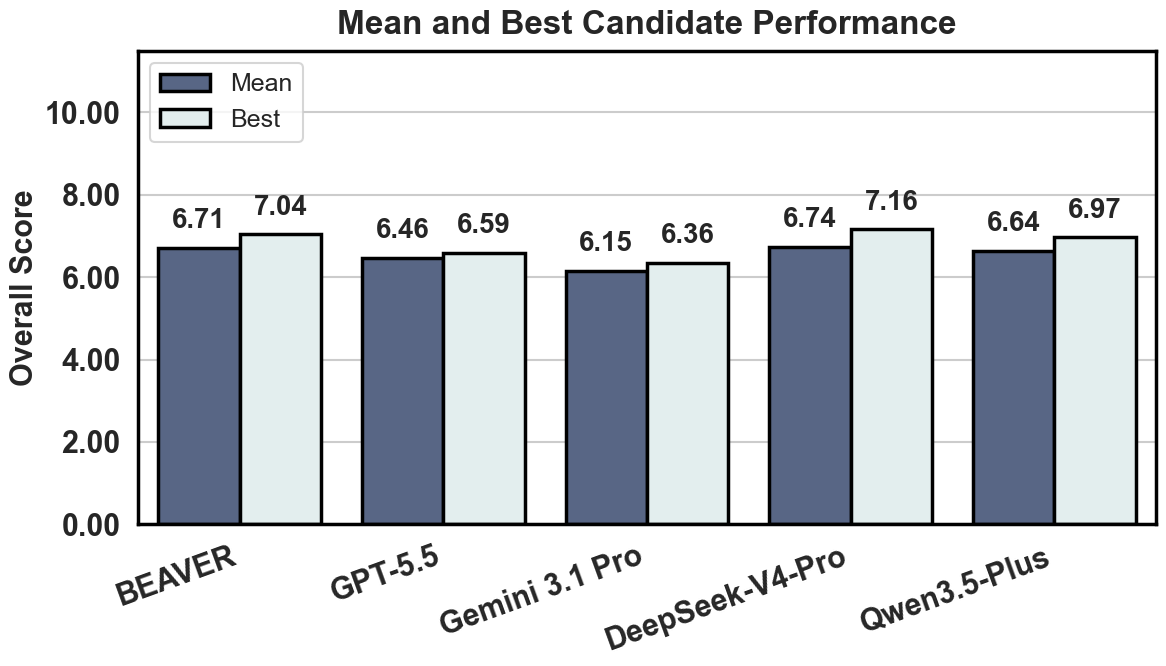

In [142]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter

# ===== 全局字号设置 (严格参考 BERT_COS 脚本) =====
FS_TITLE = 24         # 子图标题
FS_LABEL = 22         # x/y轴标题
FS_TICK = 22          # 坐标轴刻度
FS_ANNOT = 20         # 柱子上数值
FS_LEGEND = 18        # 图例文字

def annotate_bars(ax):
    """数值标注函数，与 BERT_COS 保持一致"""
    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height) and height > 0:
            ax.annotate(
                f"{height:.2f}", # 这里保留两位小数
                (p.get_x() + p.get_width() / 2., height),
                ha='center',
                va='bottom',
                fontsize=FS_ANNOT,
                fontweight='bold',
                xytext=(0, 10),
                textcoords='offset points'
            )

def style_spines(ax, lw=2.5):
    """边框加粗函数，与 BERT_COS 保持一致"""
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(lw)

def plot_family_mean_vs_best(df_mean: pd.DataFrame, df_best: pd.DataFrame):
    if df_mean.empty or df_best.empty:
        print("Missing mean or best data.")
        return

    # --- 数据处理 ---
    mean_df = order_family_df(df_mean, "Family")[["Family", "Overall"]].rename(columns={"Overall": "Mean"})
    best_df = order_family_df(df_best, "Family")[["Family", "Overall"]].rename(columns={"Overall": "Best"})
    df_merged = mean_df.merge(best_df, on="Family", how="inner")

    df_plot = df_merged.melt(id_vars="Family", var_name="Type", value_name="Score")

    # 配色保留你之前选定的颜色
    palette = {
        "Mean": (80/255, 100/255, 140/255), 
        "Best": (225/255, 240/255, 240/255)  
    }

    # --- 全局主题设定 (与 BERT_COS 保持一致) ---
    sns.set_theme(style="whitegrid", context="talk", font_scale=1.0)
    
    # 画布大小
    fig, ax = plt.subplots(figsize=(12, 7))

    # --- 绘图 (严格使用 BERT_COS 的柱状图参数) ---
    sns.barplot(
        data=df_plot,
        x="Family",
        y="Score",
        hue="Type",
        palette=palette,
        ax=ax,
        capsize=0.12,
        errcolor='black',
        errwidth=1.6,
        edgecolor='black',
        linewidth=2.5
    )

    # --- 坐标轴与标题设置 ---
    ax.set_title("Mean and Best Candidate Performance", fontsize=FS_TITLE, fontweight='bold', pad=12)
    ax.set_xlabel("") 
    ax.set_ylabel("Overall Score", fontsize=FS_LABEL, fontweight='bold')
    
    # X 轴刻度 (保留了旋转，并套用统一字号)
    families = [prettify_family(f) for f in df_merged["Family"]]
    ax.set_xticklabels(families, fontsize=FS_TICK, fontweight='bold', rotation=20, ha="right")
    
    # Y 轴范围与格式化 (套用 FormatStrFormatter 与统一字号)
    ax.set_ylim(0, 11.5)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.tick_params(axis='y', labelsize=FS_TICK)
    plt.setp(ax.get_yticklabels(), fontweight='bold')

    # --- 调用拆分的辅助函数 ---
    annotate_bars(ax)         # 添加数值标签
    style_spines(ax, lw=2.5)  # 加粗全局边框

    # --- 图例 (严格采用 BERT_COS 中的设定) ---
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles, labels,
        fontsize=FS_LEGEND,
        loc='upper left'
    )

    fig.tight_layout()
    
    # 保存与显示
    if 'savefig_multi' in globals():
        savefig_multi(fig, "Fig2_family_mean_vs_best_styled")
    
    plt.show()

# 调用
plot_family_mean_vs_best(df_family_mean, df_family_best)

Saved: ..\Judge_output\_DesignJudge_claude2\_paper_figures\Fig3_family_metric_heatmap


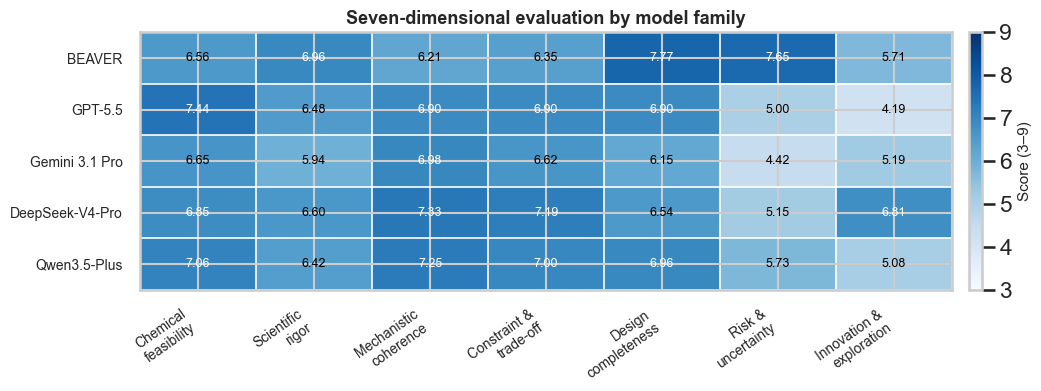

In [143]:
# =========================
# Figure 3. Seven-dimensional family heatmap
# =========================

def plot_metric_heatmap_matplotlib(df_family_mean: pd.DataFrame):
    if df_family_mean.empty:
        print("No df_family_mean")
        return

    df = order_family_df(df_family_mean, "Family")
    data = df[METRIC_COLUMNS].astype(float).values
    row_labels = [prettify_family(f) for f in df["Family"]]
    col_labels = [METRIC_LABELS[m] for m in METRIC_COLUMNS]

    # 建议用于 LLM Judge 结果的显示区间
    # 0–10 会压缩高分段差异；3–9 更适合展示 6–9 分之间的变化
    vmin, vmax = 3, 9

    fig_h = max(3.8, 0.55 * len(row_labels) + 1.5)
    fig, ax = plt.subplots(figsize=(10.8, fig_h))

    # 数值越高，颜色越深
    im = ax.imshow(data, vmin=vmin, vmax=vmax, aspect="auto", cmap="Blues")

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label("Score (3–9)", fontsize=11)
    cbar.set_ticks(np.arange(vmin, vmax + 1, 1))

    ax.set_xticks(np.arange(len(col_labels)))
    ax.set_xticklabels(col_labels, rotation=35, ha="right", fontsize=10)
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=10)

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]

            # 高分区域颜色更深，所以用白字；低分区域用黑字
            text_color = "white" if val > 6.8 else "black"

            ax.text(
                j, i, f"{val:.2f}",
                ha="center",
                va="center",
                fontsize=9,
                color=text_color
            )

    ax.set_title(
        "Seven-dimensional evaluation by model family",
        fontsize=13,
        fontweight="bold"
    )
    ax.set_xlabel("")
    ax.set_ylabel("")

    # 网格线
    ax.set_xticks(np.arange(data.shape[1] + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(data.shape[0] + 1) - 0.5, minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.2)
    ax.tick_params(which="minor", bottom=False, left=False)

    fig.tight_layout()
    savefig_multi(fig, "Fig3_family_metric_heatmap")
    plt.show()

plot_metric_heatmap_matplotlib(df_family_mean)

Saved: ..\Judge_output\_DesignJudge_claude2\_paper_figures\Fig4_family_metric_radar


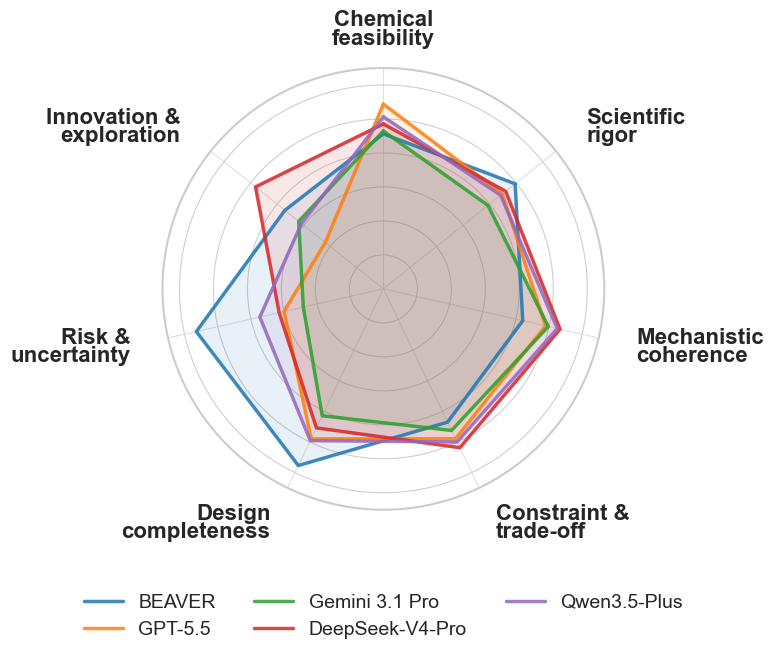

In [144]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 辅助对齐函数（提取自参考脚本）
# =========================
def format_xtick_alignment(ax, angles):
    labels = ax.get_xticklabels()
    for angle, label in zip(angles[:-1], labels):
        deg = np.degrees(angle)
        
        # 处理浮点数精度问题
        if np.isclose(deg, 0) or np.isclose(deg, 180) or np.isclose(deg, 360):
            ha = "center"
        elif 0 < deg < 180:
            ha = "left"
        else:
            ha = "right"

        label.set_horizontalalignment(ha)
        label.set_verticalalignment("center")
        label.set_linespacing(0.9)

# =========================
# Figure 4. Radar plot for seven metrics
# =========================
def plot_radar_family_metrics(df_family_mean: pd.DataFrame):
    if df_family_mean.empty:
        print("No df_family_mean")
        return

    # --- 全局风格设置 (参考脚本) ---
    plt.rcParams["font.family"] = "Arial"
    # 增加坐标轴边框粗细，让图表看起来更稳重
    plt.rcParams["axes.linewidth"] = 1.5

    df = order_family_df(df_family_mean, "Family")
    metrics = METRIC_COLUMNS
    labels = [METRIC_LABELS[m] for m in metrics]

    angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]

    # --- 画布设置 (参考脚本：白色背景) ---
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    fig.patch.set_facecolor("white") 
    ax.set_facecolor("white") 

    for _, row in df.iterrows():
        family = row["Family"]
        values = [float(row[m]) for m in metrics]
        values += values[:1]

        # --- 【关键修改1：增大线宽】 (参考脚本的粗细和透明度) ---
        ax.plot(
            angles,
            values,
            # 将线宽从1.5增大到2.5，让线条更明显
            linewidth=2.5,   
            # 增加线条不透明度
            alpha=0.85,      
            label=prettify_family(family),
            color=COLOR_MAP.get(family, None)
        )
        ax.fill(
            angles,
            values,
            # 单张叠加图的填充透明度改为0.10，避免太混杂
            alpha=0.10,      
            color=COLOR_MAP.get(family, None)
        )

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    # --- 【关键修改2：减小维度标签字号】 从25减到16号 ---
    ax.set_xticks(angles[:-1])
    # 16号字体加粗在标准屏幕上依然清晰可读，且不会过度挤压图表
    ax.set_xticklabels(labels, fontsize=16, fontweight="bold")
    ax.tick_params(axis="x", pad=12) # 适当增加文字与图表的间距
    
    # 应用文字对齐处理，防止文字与雷达图重叠
    format_xtick_alignment(ax, angles)

    # --- 半径范围、网格与刻度：隐藏数字，使用定制灰度网格 ---
    ax.set_ylim(2, 8.5)
    ax.set_yticks([3, 4, 5, 6, 7, 8])
    # 隐藏具体的雷达圈数字，保持画面干净
    ax.set_yticklabels([])  
    # 使用参考脚本的灰度网格
    ax.yaxis.grid(True, color="#CFCFCF", lw=0.8)
    ax.xaxis.grid(True, color="#E0E0E0", lw=0.8)

    ax.set_title(
        "",
        fontsize=22,
        fontweight="bold",
        pad=30
    )

    ax.legend(
        loc='upper center',          
        bbox_to_anchor=(0.5, -0.15), # 移到雷达图正下方，增加一点负间距
        ncol=3,                      # 变为3列排布，实现多行对齐
        fontsize=14,                 # 图例字体调整到14号
        frameon=False                # 去除边框
    )

    # 自动调整布局，让所有元素都在画布内
    fig.tight_layout()
    # 保存时使用高质量参数
    # 如果你的 savefig_multi 支持，请确保传入 dpi=600, bbox_inches="tight"
    savefig_multi(fig, "Fig4_family_metric_radar")
    plt.show()

plot_radar_family_metrics(df_family_mean)

Saved: ..\Judge_output\_DesignJudge_claude2\_paper_figures\Fig5_case_family_overall_heatmap


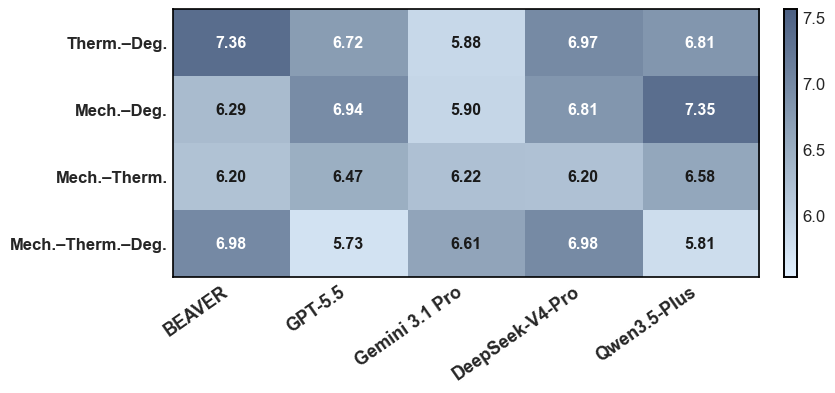

Family,BEAVER,GPT5.5,Gemini3.1-pro,DeepSeek-V4-pro,Qwen3.5-Plus
case_name,,,,,
热学+降解,7.363000,6.717333,5.878333,6.970333,6.814000
力学+降解,6.287000,6.937333,5.899333,6.814000,7.348000
力学+热学,6.196667,6.472667,6.217667,6.199333,6.578333
力学+热学+降解,6.982667,5.732333,6.611667,6.975000,5.805333


In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# =========================
# Figure 5. Per-case family overall heatmap
# =========================

CASE_DISPLAY_SHORT = {
    "热学+降解": "Therm.–Deg.",
    "力学+降解": "Mech.–Deg.",
    "力学+热学": "Mech.–Therm.",
    "力学+热学+降解": "Mech.–Therm.–Deg.",

    # 兼容 prettify_case 之后的英文形式
    "Thermal–Degradation": "Therm.–Deg.",
    "Mechanical–Degradation": "Mech.–Deg.",
    "Mechanical–Thermal": "Mech.–Therm.",
    "Mechanical–Thermal–Degradation": "Mech.–Therm.–Deg.",

    "Thermal-Degradation": "Therm.–Deg.",
    "Mechanical-Degradation": "Mech.–Deg.",
    "Mechanical-Thermal": "Mech.–Therm.",
    "Mechanical-Thermal-Degradation": "Mech.–Therm.–Deg.",
}


def get_case_short_label(case_name):
    """
    优先使用 CASE_DISPLAY_SHORT。
    如果 case_name 是中文，就直接映射；
    如果 case_name 被 prettify_case 转成英文，也能继续映射。
    """
    case_name = str(case_name)

    if case_name in CASE_DISPLAY_SHORT:
        return CASE_DISPLAY_SHORT[case_name]

    pretty = prettify_case(case_name)

    if pretty in CASE_DISPLAY_SHORT:
        return CASE_DISPLAY_SHORT[pretty]

    return pretty


def plot_case_family_heatmap(df_avg: pd.DataFrame):
    if df_avg.empty:
        print("No df_avg")
        return

    # =========================
    # Global style
    # =========================
    plt.rcParams["font.family"] = "Arial"
    plt.rcParams["axes.grid"] = False

    # =========================
    # Recompute family mean per case
    # =========================
    sub = df_avg.copy()
    sub = sub[sub["Family"].isin(FAMILY_ORDER)]

    case_family = (
        sub.groupby(["case_name", "Family"], as_index=False)["Overall"]
        .mean()
    )

    pivot = case_family.pivot(
        index="case_name",
        columns="Family",
        values="Overall"
    )

    pivot = pivot[[f for f in FAMILY_ORDER if f in pivot.columns]]

    # =========================
    # Case order
    # =========================
    case_order = [
        c for c in CASE_DISPLAY_SHORT.keys()
        if c in pivot.index
    ]

    other_cases = [
        c for c in pivot.index
        if c not in case_order
    ]

    pivot = pivot.loc[case_order + other_cases]

    data = pivot.values.astype(float)

    # 关键修改：这里不再用 prettify_case(x)，而是用短标签
    row_labels = [
        get_case_short_label(x)
        for x in pivot.index
    ]

    col_labels = [
        prettify_family(x)
        for x in pivot.columns
    ]

    # =========================
    # 自定义颜色
    # =========================
    LOW_COLOR = (225 / 255, 240 / 255, 255 / 255)
    MID_COLOR = (150 / 255, 170 / 255, 190 / 255)
    HIGH_COLOR = (75 / 255, 95 / 255, 130 / 255)

    USE_MID_COLOR = True

    if USE_MID_COLOR:
        clean_cmap = LinearSegmentedColormap.from_list(
            "custom_cmap",
            [LOW_COLOR, MID_COLOR, HIGH_COLOR]
        )
    else:
        clean_cmap = LinearSegmentedColormap.from_list(
            "custom_cmap",
            [LOW_COLOR, HIGH_COLOR]
        )

    # =========================
    # 色阶范围
    # =========================
    USE_FIXED_RANGE = False
    FIXED_VMIN = 4
    FIXED_VMAX = 10

    if USE_FIXED_RANGE:
        vmin, vmax = FIXED_VMIN, FIXED_VMAX
    else:
        finite_data = data[np.isfinite(data)]
        data_min = np.nanmin(finite_data)
        data_max = np.nanmax(finite_data)

        pad = max(0.20, 0.12 * (data_max - data_min))

        vmin = max(0, data_min - pad)
        vmax = min(10, data_max + pad)

    # =========================
    # Plot
    # =========================
    fig, ax = plt.subplots(
        figsize=(8.8, max(4.2, 0.62 * len(row_labels) + 1.8))
    )

    im = ax.imshow(
        data,
        vmin=vmin,
        vmax=vmax,
        aspect="auto",
        cmap=clean_cmap,
        interpolation="none"
    )

    # =========================
    # 去掉十字线 / 网格线
    # =========================
    ax.grid(False)
    ax.xaxis.grid(False, which="both")
    ax.yaxis.grid(False, which="both")
    ax.set_axisbelow(False)

    # =========================
    # 坐标标签
    # =========================
    ax.set_xticks(np.arange(len(col_labels)))
    ax.set_xticklabels(
        col_labels,
        rotation=35,
        ha="right",
        fontsize=13,
        fontweight="bold"
    )

    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_yticklabels(
        row_labels,
        fontsize=12,
        fontweight="bold"
    )

    # 防止 minor grid
    ax.set_xticks([], minor=True)
    ax.set_yticks([], minor=True)
    ax.tick_params(axis="both", which="both", length=0)

    # =========================
    # Add outer frame
    # =========================
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
        spine.set_color("black")

    # =========================
    # Add numbers
    # =========================
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]

            if not np.isfinite(val):
                continue

            norm_val = (val - vmin) / (vmax - vmin + 1e-12)
            text_color = "white" if norm_val > 0.58 else "#1A1A1A"

            ax.text(
                j,
                i,
                f"{val:.2f}",
                ha="center",
                va="center",
                fontsize=11.5,
                color=text_color,
                fontweight="bold"
            )

    # =========================
    # Colorbar
    # =========================
    cbar = fig.colorbar(
        im,
        ax=ax,
        fraction=0.035,
        pad=0.04
    )

    cbar.set_label(
        "",
        fontsize=14,
        fontweight="bold",
        labelpad=10
    )

    cbar.ax.tick_params(
        labelsize=12,
        length=0
    )
    
    # =========================
    # Colorbar frame
    # =========================
    cbar.outline.set_visible(True)
    cbar.outline.set_linewidth(1.2)
    cbar.outline.set_edgecolor("black")
    
    # 保险起见：同时打开 colorbar 轴的外框
    for spine in cbar.ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
        spine.set_color("black")
    
    # =========================
    # Title
    # =========================
    ax.set_title(
        "",
        fontsize=18,
        fontweight="bold",
        pad=20
    )

    fig.tight_layout()

    savefig_multi(
        fig,
        "Fig5_case_family_overall_heatmap"
    )

    plt.show()

    return pivot


case_family_matrix = plot_case_family_heatmap(df_avg)
display(case_family_matrix)

Saved: ..\Judge_output\_DesignJudge_claude2\_paper_figures\Fig6_candidate_score_distribution


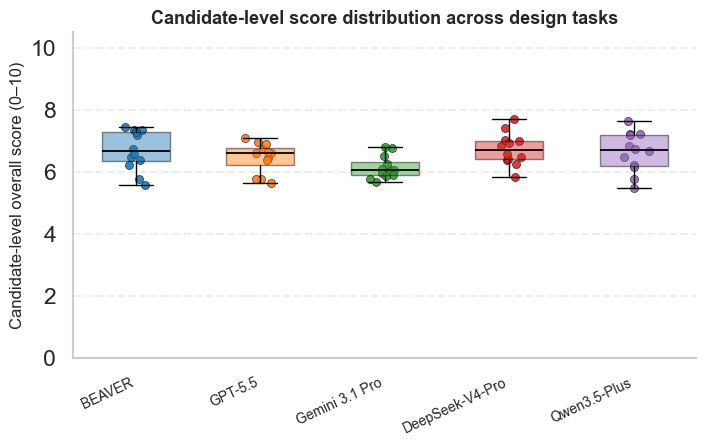

In [146]:

# =========================
# Figure 6. Candidate-level distribution by family
# =========================

def plot_family_distribution(df_avg: pd.DataFrame):
    if df_avg.empty:
        print("No df_avg")
        return

    df = df_avg.copy()
    df = df[df["Family"].isin(FAMILY_ORDER)]
    families = [f for f in FAMILY_ORDER if f in df["Family"].unique()]

    data = [df.loc[df["Family"] == f, "Overall"].astype(float).values for f in families]
    colors = [COLOR_MAP.get(f, "#777777") for f in families]

    fig, ax = plt.subplots(figsize=(7.4, 4.8))
    bp = ax.boxplot(
        data,
        positions=np.arange(len(families)),
        widths=0.55,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=1.3),
        boxprops=dict(linewidth=1.0),
        whiskerprops=dict(linewidth=1.0),
        capprops=dict(linewidth=1.0),
    )

    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.45)
        patch.set_edgecolor("black")

    # 叠加散点
    rng = np.random.default_rng(123)
    for i, vals in enumerate(data):
        jitter = rng.normal(0, 0.055, size=len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals, s=34, color=colors[i], edgecolor="black", linewidth=0.4, alpha=0.9)

    ax.set_ylabel("Candidate-level overall score (0–10)", fontsize=12)
    ax.set_ylim(0, 10.5)
    ax.set_xticks(np.arange(len(families)))
    ax.set_xticklabels([prettify_family(f) for f in families], rotation=25, ha="right", fontsize=10)
    ax.set_title("Candidate-level score distribution across design tasks", fontsize=13, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()
    savefig_multi(fig, "Fig6_candidate_score_distribution")
    plt.show()

plot_family_distribution(df_avg)


Saved: ..\Judge_output\_DesignJudge_claude2\_paper_figures\Fig7_beaver_metric_advantage


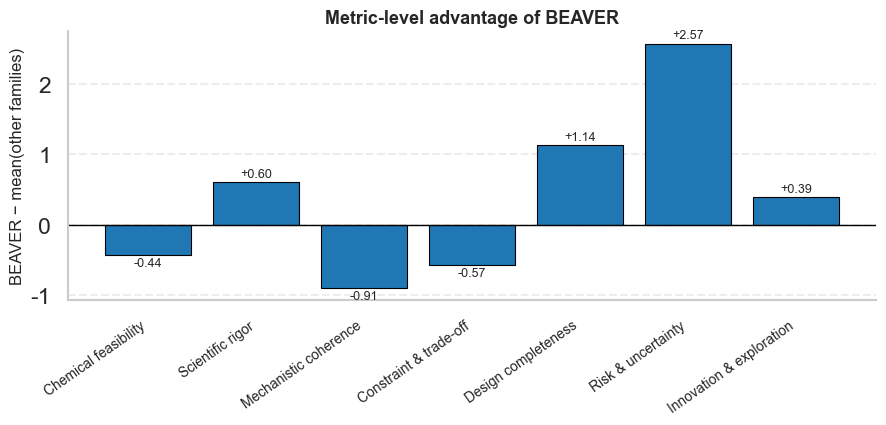

,Metric,BEAVER_minus_other_mean
0,Chemical_Feasibility,-0.43825
1,Scientific_Rigor,0.59975
2,Mechanistic_Coherence,-0.90650
3,Property_Constraint_and_Tradeoff_Handling,-0.57325
4,Design_Completeness,1.13575
5,Risk_and_Uncertainty_Awareness,2.57300
6,Design_Innovation_and_Exploration,0.39050


In [147]:

# =========================
# Figure 7. BEAVER advantage by metric
# =========================

def plot_beaver_metric_advantage(df_family_mean: pd.DataFrame):
    if df_family_mean.empty or "BEAVER" not in set(df_family_mean["Family"]):
        print("No BEAVER in df_family_mean")
        return

    df = df_family_mean.copy()
    beaver = df[df["Family"] == "BEAVER"].iloc[0]
    others = df[df["Family"] != "BEAVER"]

    adv = []
    for m in METRIC_COLUMNS:
        adv.append(float(beaver[m]) - float(others[m].astype(float).mean()))

    labels = [METRIC_LABELS[m].replace("\n", " ") for m in METRIC_COLUMNS]
    x = np.arange(len(labels))

    fig, ax = plt.subplots(figsize=(9.2, 4.6))
    bars = ax.bar(x, adv, color="#1f77b4", edgecolor="black", linewidth=0.8)
    ax.axhline(0, color="black", linewidth=1.0)

    for i, v in enumerate(adv):
        va = "bottom" if v >= 0 else "top"
        y = v + 0.03 if v >= 0 else v - 0.03
        ax.text(i, y, f"{v:+.2f}", ha="center", va=va, fontsize=9)

    ax.set_ylabel("BEAVER − mean(other families)", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=10)
    ax.set_title("Metric-level advantage of BEAVER", fontsize=13, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()
    savefig_multi(fig, "Fig7_beaver_metric_advantage")
    plt.show()

    adv_df = pd.DataFrame({"Metric": METRIC_COLUMNS, "BEAVER_minus_other_mean": adv})
    return adv_df

adv_df = plot_beaver_metric_advantage(df_family_mean)
display(adv_df)


Saved: ..\Judge_output\_DesignJudge_claude2\_paper_figures\Fig8_beaver_win_tie_loss_candidate_aligned_styled


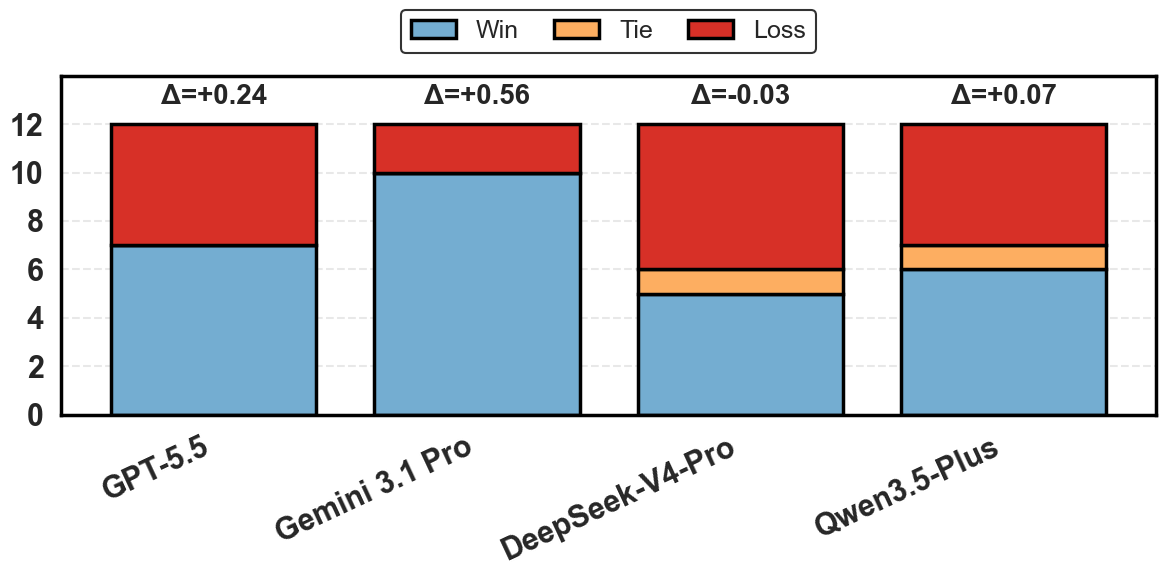

,Baseline,Win,Tie,Loss,MeanDiff,N
0,GPT5.5,7,0,5,0.242417,12
1,Gemini3.1-pro,10,0,2,0.555583,12
2,DeepSeek-V4-pro,5,1,6,-0.032333,12
3,Qwen3.5-Plus,6,1,5,0.070917,12


In [148]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter

# =========================
# Figure 8. BEAVER win/tie/loss against each baseline
# Candidate-aligned version: 4 tasks × 3 candidates = 12 comparisons
# Styled version following BERT_COS / Fig2 style
# =========================

# ===== 全局字号设置：与第二个脚本一致 =====
FS_TITLE = 24
FS_LABEL = 22
FS_TICK = 22
FS_ANNOT = 20
FS_LEGEND = 18


def style_spines(ax, lw=2.5):
    """边框加粗函数，与第二个脚本保持一致"""
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(lw)


def extract_candidate_index(candidate: str):
    s = str(candidate)

    if s.startswith("BEAVER_Paper_"):
        m = re.search(r"BEAVER_Paper_(\d+)", s)
        return int(m.group(1)) if m else None

    m = re.search(r"-(\d+)$", s)
    return int(m.group(1)) if m else None


def compute_beaver_wtl_candidate_aligned(
    df_avg: pd.DataFrame,
    tie_margin: float = 0.10
) -> pd.DataFrame:
    if df_avg.empty:
        return pd.DataFrame()

    df = df_avg.copy()
    df = df[df["Family"].isin(FAMILY_ORDER)].copy()

    df["CandidateIndex"] = df["Candidate"].apply(extract_candidate_index)
    df = df[df["CandidateIndex"].isin([1, 2, 3])].copy()

    rows = []

    for baseline in FAMILY_ORDER:
        if baseline == "BEAVER":
            continue

        sub_beaver = df[df["Family"] == "BEAVER"][
            ["case_name", "CandidateIndex", "Overall"]
        ].rename(columns={"Overall": "BEAVER_Overall"})

        sub_base = df[df["Family"] == baseline][
            ["case_name", "CandidateIndex", "Overall"]
        ].rename(columns={"Overall": "Baseline_Overall"})

        merged = sub_beaver.merge(
            sub_base,
            on=["case_name", "CandidateIndex"],
            how="inner"
        )

        if merged.empty:
            continue

        diff = merged["BEAVER_Overall"] - merged["Baseline_Overall"]

        wins = int((diff > tie_margin).sum())
        ties = int((diff.abs() <= tie_margin).sum())
        losses = int((diff < -tie_margin).sum())

        rows.append({
            "Baseline": baseline,
            "Win": wins,
            "Tie": ties,
            "Loss": losses,
            "MeanDiff": float(diff.mean()),
            "N": int(diff.notna().sum()),
        })

    return pd.DataFrame(rows)


def plot_beaver_wtl_candidate_aligned(
    df_avg: pd.DataFrame,
    tie_margin: float = 0.10
):
    wtl = compute_beaver_wtl_candidate_aligned(
        df_avg,
        tie_margin=tie_margin
    )

    if wtl.empty:
        print("No W/T/L data")
        return pd.DataFrame()

    # =========================
    # Sort by FAMILY_ORDER
    # =========================
    wtl["__order"] = wtl["Baseline"].map({
        f: i for i, f in enumerate(FAMILY_ORDER)
    })
    wtl = wtl.sort_values("__order").drop(columns="__order")

    x = np.arange(len(wtl))
    win = wtl["Win"].values
    tie = wtl["Tie"].values
    loss = wtl["Loss"].values
    total = win + tie + loss

    # =========================
    # Global theme：严格参考第二个脚本
    # =========================
    sns.set_theme(
        style="whitegrid",
        context="talk",
        font_scale=1.0
    )

    plt.rcParams["font.family"] = "Arial"
    plt.rcParams["axes.linewidth"] = 2.5

    # =========================
    # Figure
    # =========================
    fig, ax = plt.subplots(figsize=(12, 7))

    # =========================
    # Colors：保留 W/T/L 语义色，但整体风格加粗
    # =========================
    COLOR_WIN = "#74add1"
    COLOR_TIE = "#fdae61"
    COLOR_LOSS = "#d73027"

    bar_width = 0.78
    edge_lw = 2.5

    b1 = ax.bar(
        x,
        win,
        width=bar_width,
        label="Win",
        color=COLOR_WIN,
        edgecolor="black",
        linewidth=edge_lw
    )

    b2 = ax.bar(
        x,
        tie,
        width=bar_width,
        bottom=win,
        label="Tie",
        color=COLOR_TIE,
        edgecolor="black",
        linewidth=edge_lw
    )

    b3 = ax.bar(
        x,
        loss,
        width=bar_width,
        bottom=win + tie,
        label="Loss",
        color=COLOR_LOSS,
        edgecolor="black",
        linewidth=edge_lw
    )

    # =========================
    # Mean difference annotation
    # =========================
    for i in range(len(wtl)):
        ax.annotate(
            f"Δ={wtl.iloc[i]['MeanDiff']:+.2f}",
            (x[i], total[i]),
            ha="center",
            va="bottom",
            fontsize=FS_ANNOT,
            fontweight="bold",
            xytext=(0, 10),
            textcoords="offset points"
        )

    # =========================
    # Axis labels
    # =========================
    ax.set_title(
        "",
        fontsize=FS_TITLE,
        fontweight="bold",
        pad=12
    )

    ax.set_xlabel("")

    ax.set_ylabel(
        "",
        fontsize=FS_LABEL,
        fontweight="bold"
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [prettify_family(f) for f in wtl["Baseline"]],
        fontsize=FS_TICK,
        fontweight="bold",
        rotation=25,
        ha="right"
    )

    ax.set_ylim(0, max(14, total.max() + 2))
    ax.set_yticks(np.arange(0, 13, 2))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))

    ax.tick_params(axis="y", labelsize=FS_TICK)
    plt.setp(ax.get_yticklabels(), fontweight="bold")

    # =========================
    # Grid and spines：与第二个脚本统一
    # =========================
    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=1.5,
        alpha=0.45
    )

    ax.grid(
        axis="x",
        visible=False
    )

    style_spines(ax, lw=2.5)

    # 如果你想保留完整黑框，就不要隐藏 top/right
    # 如果想更简洁，可以取消下面两行注释
    # ax.spines["top"].set_visible(False)
    # ax.spines["right"].set_visible(False)

    # =========================
    # Legend：采用第二个脚本的风格
    # =========================
    handles, labels = ax.get_legend_handles_labels()

    ax.legend(
        handles,
        labels,
        fontsize=FS_LEGEND,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.03),
        ncol=3,
        frameon=True,
        edgecolor="black",
        columnspacing=1.4,
        handlelength=1.8
    )
    
    # 给上方图例留空间
    fig.tight_layout(rect=[0, 0, 1, 0.88])

    savefig_multi(
        fig,
        "Fig8_beaver_win_tie_loss_candidate_aligned_styled"
    )

    plt.show()

    return wtl


wtl_df_12 = plot_beaver_wtl_candidate_aligned(
    df_avg,
    tie_margin=0.10
)

display(wtl_df_12)

Saved: ..\Judge_output\_DesignJudge_claude2\_paper_figures\Fig9_objective_design_space_exploration


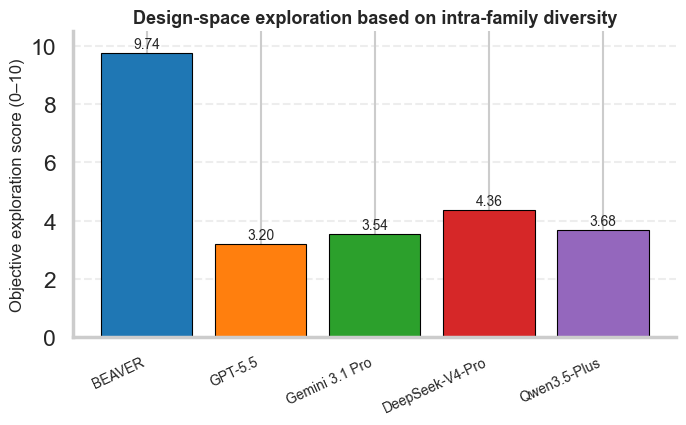

In [149]:

# =========================
# Figure 9. Objective design-space exploration
# =========================

def plot_objective_exploration(df_family_exp: pd.DataFrame):
    if df_family_exp.empty or "Objective_Design_Space_Exploration" not in df_family_exp.columns:
        print("No objective exploration data.")
        return

    df = order_family_df(df_family_exp, "Family")
    labels = [prettify_family(f) for f in df["Family"]]
    values = df["Objective_Design_Space_Exploration"].astype(float).values
    colors = [COLOR_MAP.get(f, "#777777") for f in df["Family"]]

    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    ax.bar(np.arange(len(df)), values, color=colors, edgecolor="black", linewidth=0.8)

    for i, v in enumerate(values):
        ax.text(i, v + 0.08, f"{v:.2f}", ha="center", va="bottom", fontsize=10)

    ax.set_ylabel("Objective exploration score (0–10)", fontsize=12)
    ax.set_ylim(0, 10.5)
    ax.set_xticks(np.arange(len(df)))
    ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=10)
    ax.set_title("Design-space exploration based on intra-family diversity", fontsize=13, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()
    savefig_multi(fig, "Fig9_objective_design_space_exploration")
    plt.show()

plot_objective_exploration(df_family_exp)


Saved: ..\Judge_output\_DesignJudge_claude2\_paper_figures\Fig10_overall_vs_exploration_adjusted


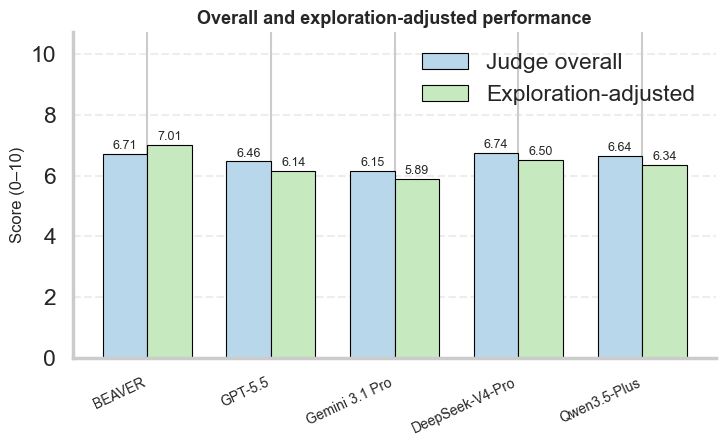

In [150]:

# =========================
# Figure 10. Overall vs exploration-adjusted overall
# =========================

def plot_overall_vs_exploration_adjusted(df_family_exp: pd.DataFrame):
    if df_family_exp.empty or "Exploration_Adjusted_Overall" not in df_family_exp.columns:
        print("No exploration-adjusted overall data.")
        return

    df = order_family_df(df_family_exp, "Family")
    x = np.arange(len(df))
    width = 0.36

    fig, ax = plt.subplots(figsize=(7.6, 4.8))
    b1 = ax.bar(x - width/2, df["Overall"], width, label="Judge overall", color="#b9d7ea", edgecolor="black", linewidth=0.8)
    b2 = ax.bar(x + width/2, df["Exploration_Adjusted_Overall"], width, label="Exploration-adjusted", color="#c7e9c0", edgecolor="black", linewidth=0.8)

    for bars in [b1, b2]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.06, f"{h:.2f}", ha="center", va="bottom", fontsize=9)

    ax.set_ylabel("Score (0–10)", fontsize=12)
    ax.set_ylim(0, 10.7)
    ax.set_xticks(x)
    ax.set_xticklabels([prettify_family(f) for f in df["Family"]], rotation=25, ha="right", fontsize=10)
    ax.set_title("Overall and exploration-adjusted performance", fontsize=13, fontweight="bold")
    ax.legend(frameon=False)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()
    savefig_multi(fig, "Fig10_overall_vs_exploration_adjusted")
    plt.show()

plot_overall_vs_exploration_adjusted(df_family_exp)


In [151]:

# =========================
# Export summary tables
# =========================

SUMMARY_DIR = OUTPUT_DIR / "_paper_tables"
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

# Table 1: family mean scores
if not df_family_mean.empty:
    table_family_mean = order_family_df(df_family_mean, "Family").copy()
    table_family_mean["Family_display"] = table_family_mean["Family"].map(prettify_family)
    cols = ["Family_display", "Overall"] + METRIC_COLUMNS + ["ScoredCases", "JudgeParseOK(%)"]
    table_family_mean = table_family_mean[[c for c in cols if c in table_family_mean.columns]]
    table_family_mean.to_csv(SUMMARY_DIR / "Table_family_mean_scores.csv", index=False, encoding="utf-8-sig")
    display(table_family_mean)

# Table 2: BEAVER W/T/L
if "wtl_df" in globals() and isinstance(wtl_df, pd.DataFrame) and not wtl_df.empty:
    out = wtl_df.copy()
    out["Baseline_display"] = out["Baseline"].map(prettify_family)
    out.to_csv(SUMMARY_DIR / "Table_BEAVER_win_tie_loss.csv", index=False, encoding="utf-8-sig")
    display(out)

# Table 3: metric advantage
if "adv_df" in globals() and isinstance(adv_df, pd.DataFrame) and not adv_df.empty:
    out = adv_df.copy()
    out["Metric_display"] = out["Metric"].map(lambda x: METRIC_LABELS.get(x, x).replace("\n", " "))
    out.to_csv(SUMMARY_DIR / "Table_BEAVER_metric_advantage.csv", index=False, encoding="utf-8-sig")
    display(out)

print("Tables saved to:", SUMMARY_DIR)
print("Figures saved to:", FIG_DIR)


,Family_display,Overall,Chemical_Feasibility,Scientific_Rigor,Mechanistic_Coherence,Property_Constraint_and_Tradeoff_Handling,Design_Completeness,Risk_and_Uncertainty_Awareness,Design_Innovation_and_Exploration,ScoredCases,JudgeParseOK(%)
0,BEAVER,6.708,6.562,6.959,6.208,6.354,7.771,7.646,5.708,4,100.0
1,GPT-5.5,6.465,7.438,6.479,6.896,6.896,6.896,5.000,4.188,4,100.0
2,Gemini 3.1 Pro,6.152,6.646,5.938,6.979,6.625,6.146,4.417,5.187,4,100.0
3,DeepSeek-V4-Pro,6.740,6.854,6.604,7.333,7.188,6.541,5.146,6.812,4,100.0
4,Qwen3.5-Plus,6.636,7.063,6.416,7.250,7.000,6.958,5.729,5.083,4,100.0


,Metric,BEAVER_minus_other_mean,Metric_display
0,Chemical_Feasibility,-0.43825,Chemical feasibility
1,Scientific_Rigor,0.59975,Scientific rigor
2,Mechanistic_Coherence,-0.90650,Mechanistic coherence
3,Property_Constraint_and_Tradeoff_Handling,-0.57325,Constraint & trade-off
4,Design_Completeness,1.13575,Design completeness
5,Risk_and_Uncertainty_Awareness,2.57300,Risk & uncertainty
6,Design_Innovation_and_Exploration,0.39050,Innovation & exploration


Tables saved to: ..\Judge_output\_DesignJudge_claude2\_paper_tables
Figures saved to: ..\Judge_output\_DesignJudge_claude2\_paper_figures


In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
from pathlib import Path

# =========================
# 修改为你的输出目录
# =========================
OUT_DIR = OUTPUT_DIR

# =========================
# 输入文件
# =========================
FORWARD_CSV = OUT_DIR / "2_item_scores_forward.csv"
REVERSE_CSV = OUT_DIR / "2_item_scores_reverse.csv"
AVG_CSV     = OUT_DIR / "3_item_scores_average_per_candidate.csv"

# =========================
# 输出文件
# =========================
FAMILY_DIM_SUMMARY_CSV = OUT_DIR / "summary_family_dimension_forward_reverse_average.csv"
CASE_FAMILY_OVERALL_CSV = OUT_DIR / "summary_case_family_overall_forward_reverse_average.csv"
CANDIDATE_DIM_SUMMARY_CSV = OUT_DIR / "summary_candidate_dimension_forward_reverse_average.csv"

METRIC_COLUMNS = [
    "Chemical_Feasibility",
    "Scientific_Rigor",
    "Mechanistic_Coherence",
    "Property_Constraint_and_Tradeoff_Handling",
    "Design_Completeness",
    "Risk_and_Uncertainty_Awareness",
    "Design_Innovation_and_Exploration",
    "Overall",
]

FAMILY_ORDER = [
    "BEAVER",
    "GPT5.5",
    "Gemini3.1-pro",
    "DeepSeek-V4-pro",
    "Qwen3.5-Plus",
]


def read_score_csv(path: Path, setting: str) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    df = pd.read_csv(path)
    df["Setting"] = setting
    return df


def order_family(df: pd.DataFrame) -> pd.DataFrame:
    df["Family"] = pd.Categorical(df["Family"], categories=FAMILY_ORDER, ordered=True)
    return df.sort_values(["Family"]).reset_index(drop=True)


# =========================
# 1. 读取 Forward / Reverse / Average
# =========================
df_forward = read_score_csv(FORWARD_CSV, "Forward")
df_reverse = read_score_csv(REVERSE_CSV, "Reverse")
df_avg = read_score_csv(AVG_CSV, "Forward-Reverse Average")

df_all = pd.concat([df_forward, df_reverse, df_avg], ignore_index=True)

# =========================
# 2. 每个模型 family 的各维度分数
#    用于看图 b 的来源，也能比较顺序敏感性
# =========================
family_dim_summary = (
    df_all
    .groupby(["Setting", "Family"], as_index=False)[METRIC_COLUMNS]
    .mean()
)

for col in METRIC_COLUMNS:
    family_dim_summary[col] = family_dim_summary[col].round(3)

family_dim_summary["Family"] = pd.Categorical(
    family_dim_summary["Family"],
    categories=FAMILY_ORDER,
    ordered=True
)

setting_order = ["Forward", "Reverse", "Forward-Reverse Average"]
family_dim_summary["Setting"] = pd.Categorical(
    family_dim_summary["Setting"],
    categories=setting_order,
    ordered=True
)

family_dim_summary = family_dim_summary.sort_values(["Setting", "Family"]).reset_index(drop=True)
family_dim_summary.to_csv(FAMILY_DIM_SUMMARY_CSV, index=False, encoding="utf-8-sig")

# =========================
# 3. 每个 candidate 的各维度分数
#    同时附加每个 family 的平均分
# =========================

candidate_dim_summary = (
    df_all
    .groupby(["Setting", "Family", "Candidate"], as_index=False)[METRIC_COLUMNS]
    .mean()
)

# 每个模型 family 的平均分
family_mean_as_candidate_rows = (
    df_all
    .groupby(["Setting", "Family"], as_index=False)[METRIC_COLUMNS]
    .mean()
)

family_mean_as_candidate_rows["Candidate"] = family_mean_as_candidate_rows["Family"].astype(str) + "_Mean"

# 调整列顺序
family_mean_as_candidate_rows = family_mean_as_candidate_rows[
    ["Setting", "Family", "Candidate"] + METRIC_COLUMNS
]

# 合并 candidate rows 和 family mean rows
candidate_dim_summary = pd.concat(
    [candidate_dim_summary, family_mean_as_candidate_rows],
    ignore_index=True
)

for col in METRIC_COLUMNS:
    candidate_dim_summary[col] = candidate_dim_summary[col].round(3)

candidate_dim_summary["Family"] = pd.Categorical(
    candidate_dim_summary["Family"],
    categories=FAMILY_ORDER,
    ordered=True
)

candidate_dim_summary["Setting"] = pd.Categorical(
    candidate_dim_summary["Setting"],
    categories=setting_order,
    ordered=True
)

# 排序：每个 family 下先列 1/2/3，再列 Mean
def candidate_sort_key(x):
    x = str(x)
    if x.endswith("_Mean"):
        return 99
    nums = re.findall(r"(\d+)$", x)
    return int(nums[0]) if nums else 50

import re
candidate_dim_summary["__cand_order"] = candidate_dim_summary["Candidate"].apply(candidate_sort_key)

candidate_dim_summary = candidate_dim_summary.sort_values(
    ["Setting", "Family", "__cand_order", "Candidate"]
).drop(columns="__cand_order").reset_index(drop=True)

candidate_dim_summary.to_csv(
    CANDIDATE_DIM_SUMMARY_CSV,
    index=False,
    encoding="utf-8-sig"
)
# =========================
# 4. 不同问题 × 每个模型 family 的 Overall
#    用于看图 c 的来源
# =========================
case_family_overall = (
    df_all
    .groupby(["Setting", "case_name", "Family"], as_index=False)["Overall"]
    .mean()
)

case_family_overall["Overall"] = case_family_overall["Overall"].round(3)

case_family_overall["Family"] = pd.Categorical(
    case_family_overall["Family"],
    categories=FAMILY_ORDER,
    ordered=True
)

case_family_overall["Setting"] = pd.Categorical(
    case_family_overall["Setting"],
    categories=setting_order,
    ordered=True
)

case_family_overall = case_family_overall.sort_values(
    ["Setting", "case_name", "Family"]
).reset_index(drop=True)

case_family_overall.to_csv(CASE_FAMILY_OVERALL_CSV, index=False, encoding="utf-8-sig")

print("Done.")
print(f"Family dimension summary saved to:\n{FAMILY_DIM_SUMMARY_CSV}")
print(f"Candidate dimension summary saved to:\n{CANDIDATE_DIM_SUMMARY_CSV}")
print(f"Case-family Overall summary saved to:\n{CASE_FAMILY_OVERALL_CSV}")

In [ ]:
# -*- coding: utf-8 -*-
import re
import pandas as pd
from pathlib import Path

# =========================
# 改成你的 Design Judge 输出目录
# =========================
OUT_DIR = OUTPUT_DIR

# =========================
# 输入文件：双向平均后的候选级七维分数
# =========================
AVG_CSV = OUT_DIR / "3_item_scores_average_per_candidate.csv"

# =========================
# 输出文件
# =========================
OUT_CSV = OUT_DIR / "summary_case_family_candidate_plus_mean_dimension_average.csv"

METRIC_COLUMNS = [
    "Chemical_Feasibility",
    "Scientific_Rigor",
    "Mechanistic_Coherence",
    "Property_Constraint_and_Tradeoff_Handling",
    "Design_Completeness",
    "Risk_and_Uncertainty_Awareness",
    "Design_Innovation_and_Exploration",
    "Overall",
]

FAMILY_ORDER = [
    "BEAVER",
    "GPT5.5",
    "Gemini3.1-pro",
    "DeepSeek-V4-pro",
    "Qwen3.5-Plus",
]

CASE_ORDER = [
    "热学+降解",
    "力学+降解",
    "力学+热学",
    "力学+热学+降解",
]


def candidate_sort_key(candidate: str) -> int:
    s = str(candidate)
    if s.endswith("_Mean"):
        return 99
    m = re.search(r"(\d+)$", s)
    if m:
        return int(m.group(1))
    return 50


# =========================
# 1. 读取双向平均候选级分数
# =========================
df = pd.read_csv(AVG_CSV)

missing_cols = [c for c in METRIC_COLUMNS if c not in df.columns]
if missing_cols:
    raise ValueError(
        f"输入文件缺少这些列：{missing_cols}\n"
        f"请确认输入文件是 3_item_scores_average_per_candidate.csv"
    )

needed_cols = ["case_name", "Family", "Candidate"] + METRIC_COLUMNS
df_candidate = df[needed_cols].copy()

# =========================
# 2. 生成每个约束场景 × 每个 family 的 Mean 行
#    即：同一 case_name + Family 下，三个候选取平均
# =========================
df_mean = (
    df_candidate
    .groupby(["case_name", "Family"], as_index=False)[METRIC_COLUMNS]
    .mean()
)

df_mean["Candidate"] = df_mean["Family"].astype(str) + "_Mean"
df_mean = df_mean[needed_cols]

# =========================
# 3. 合并 candidate 行和 family mean 行
# =========================
df_out = pd.concat([df_candidate, df_mean], ignore_index=True)

# =========================
# 4. 保留三位小数
# =========================
for col in METRIC_COLUMNS:
    df_out[col] = df_out[col].round(3)

# =========================
# 5. 排序：场景 → family → 1/2/3 → Mean
# =========================
df_out["case_name"] = pd.Categorical(
    df_out["case_name"],
    categories=CASE_ORDER,
    ordered=True,
)

df_out["Family"] = pd.Categorical(
    df_out["Family"],
    categories=FAMILY_ORDER,
    ordered=True,
)

df_out["__candidate_order"] = df_out["Candidate"].apply(candidate_sort_key)

df_out = (
    df_out
    .sort_values(["case_name", "Family", "__candidate_order", "Candidate"])
    .drop(columns="__candidate_order")
    .reset_index(drop=True)
)

# =========================
# 6. 保存
# =========================
df_out.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

print("Done.")
print(f"Saved to:\n{OUT_CSV}")